# Cognitive LLM — Phase 1: Colab T4 Debug Notebook

This notebook implements Phase 1 of the Cognitive LLM Architecture:
- Load SmolLM3 3B with 4-bit quantization
- Inject Block 1 (SurpriseGate) + Block 6 (HomeostaticNorm)
- Run a verified forward pass on the cognitive wrapper
- Train a short debug run on a GSM8K subset
- Verify loss is moving in the right direction
- Evaluate on a small GSM8K sample


In [1]:
# Install dependencies
%pip install -q transformers datasets accelerate bitsandbytes peft trl wandb lm-eval pyyaml matplotlib


In [2]:
# Clone/update repo and ensure latest code is loaded
from pathlib import Path
import os
import subprocess
import sys

repo_dir = Path('/content/cognitive-llm')

# Always force a fresh clone to avoid stale code
if repo_dir.exists():
    import shutil
    shutil.rmtree(repo_dir)

subprocess.run(
    ['git', 'clone', 'https://github.com/RiyadMehdi7/cognitive-llm.git', str(repo_dir)],
    check=True,
)
os.chdir(repo_dir)

print(f'Working directory: {Path.cwd()}')
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

# Clear any cached modules
for name in list(sys.modules):
    if name.startswith('cognitive_llm'):
        del sys.modules[name]

print('Ready — using latest code from GitHub')

Working directory: /content/cognitive-llm
Ready — using latest code from GitHub


In [3]:
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

assert torch.cuda.is_available(), 'GPU runtime required'
print(f'cwd: {os.getcwd()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


cwd: /content/cognitive-llm
GPU: Tesla T4
Memory: 15.6 GB


In [4]:
# Load SmolLM3 3B with 4-bit quantization for Colab T4
model_id = 'HuggingFaceTB/SmolLM3-3B'

capability = torch.cuda.get_device_capability(0)
use_bf16 = capability[0] >= 8
compute_dtype = torch.bfloat16 if use_bf16 else torch.float16
print(f'Using compute dtype: {compute_dtype}')

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map='auto',
    dtype=compute_dtype,
)

model_device = base_model.get_input_embeddings().weight.device
print(f'Model device: {model_device}')
print(f'Model loaded: {base_model.config.hidden_size}d, {base_model.config.num_hidden_layers} layers')


Using compute dtype: torch.float16


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

Model device: cuda:0
Model loaded: 2048d, 36 layers


In [ ]:
# Apply LoRA adapters to the base model (QLoRA pattern)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

base_model = prepare_model_for_kbit_training(base_model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

base_model = get_peft_model(base_model, lora_config)
base_model.print_trainable_parameters()

# Wrap with Cognitive blocks (B1 + B2 + B6 for Phase 1)
from cognitive_llm.models.cognitive_model import CognitiveModel

config = {
    'use_block1': True,   # Surprise gate ON
    'use_block2': True,   # Episodic memory ON
    'use_block3': False,
    'use_block4': False,
    'use_block5': False,
    'use_block6': True,   # HomeostaticNorm always ON
}

model = CognitiveModel(base_model, config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nCognitiveModel created successfully (B1+B2+B6)')
print(f'Trainable params: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.2f}%)')

# Quick forward pass test
test_inputs = tokenizer('Hello world', return_tensors='pt').to('cuda')
with torch.no_grad():
    outputs = model(
        test_inputs['input_ids'],
        attention_mask=test_inputs['attention_mask'],
    )
print(f'Logits shape: {outputs["logits"].shape}')
print('Forward pass OK!')

In [6]:
# Load a smaller GSM8K subset for fast Colab debug
from datasets import load_dataset

dataset = load_dataset('gsm8k', 'main', split='train[:128]')
print(f'GSM8K samples: {len(dataset)}')
print(f'Example: {dataset[0]["question"][:100]}...')


GSM8K samples: 128
Example: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How m...


In [7]:
# Tokenize dataset
MAX_SEQ_LEN = 256

def tokenize_gsm8k(examples):
    texts = [
        f'Question: {q}\nAnswer: {a}'
        for q, a in zip(examples['question'], examples['answer'])
    ]
    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=MAX_SEQ_LEN,
        padding='max_length',
    )
    tokenized['labels'] = [ids.copy() for ids in tokenized['input_ids']]
    return tokenized

tokenized_dataset = dataset.map(
    tokenize_gsm8k,
    batched=True,
    remove_columns=dataset.column_names,
    desc='Tokenizing GSM8K',
)
tokenized_dataset.set_format(type='torch')

from torch.utils.data import DataLoader
train_loader = DataLoader(tokenized_dataset, batch_size=1, shuffle=True)


In [8]:
# Train 100 optimizer steps (800 forward passes with grad_accum=8)
from cognitive_llm.training.trainer import CognitiveTrainer

training_config = {
    'learning_rate': 5e-5,       # reduced from 2e-4 for stability
    'max_steps': 800,            # 800 / grad_accum(8) = 100 optimizer steps
    'warmup_steps': 10,
    'gradient_accumulation': 8,
    'max_grad_norm': 1.0,
    'eval_every_n_steps': 50,
    'save_every_n_steps': 100,
    'use_wandb': False,
}

trainer = CognitiveTrainer(
    model=model,
    train_dataloader=train_loader,
    config=training_config,
)

losses = trainer.train()
print(f'Training complete! Final loss: {losses[-1]:.4f}')

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step 10: loss=2.8669 lm_loss=2.8667
Step 20: loss=1.0421 lm_loss=1.0419
Step 30: loss=0.6599 lm_loss=0.6597
Step 40: loss=0.6192 lm_loss=0.6190
Step 50: loss=0.5543 lm_loss=0.5541
Step 60: loss=0.4923 lm_loss=0.4921
Step 70: loss=0.3841 lm_loss=0.3840
Step 80: loss=0.4951 lm_loss=0.4949
Step 90: loss=0.4122 lm_loss=0.4121
Step 100: loss=0.4416 lm_loss=0.4414
  Checkpoint saved: checkpoints/cognitive_step100_blocks100001.pt
Training complete! Final loss: 0.4416


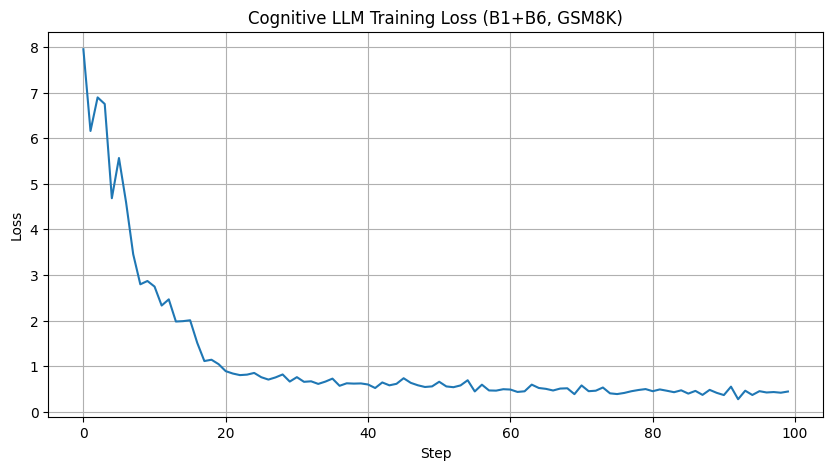

First 10 avg: 5.1716, Last 10 avg: 0.4167
Loss is DECREASING — training is working!


In [9]:
# Plot loss curve — must be decreasing
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Cognitive LLM Training Loss (B1+B6, GSM8K)')
plt.grid(True)
plt.show()

# Verify loss is decreasing
if len(losses) > 10:
    first_10 = sum(losses[:10]) / 10
    last_10 = sum(losses[-10:]) / 10
    print(f'First 10 avg: {first_10:.4f}, Last 10 avg: {last_10:.4f}')
    if last_10 < first_10:
        print('Loss is DECREASING — training is working!')
    else:
        print('WARNING: Loss is NOT decreasing — check configuration!')

In [10]:
# Quick baseline scoring on a small GSM8K sample
test_dataset = load_dataset('gsm8k', 'main', split='test[:10]')

correct = 0
total = 0

model.train(False)
for example in test_dataset:
    prompt = f"Question: {example['question']}\nAnswer:"
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_SEQ_LEN,
    ).to(model_device)

    with torch.no_grad():
        generated = base_model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False,
        )

    response = tokenizer.decode(generated[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

    import re
    pred_match = re.search(r'####\s*([-\d,\.]+)', response)
    target_match = re.search(r'####\s*([-\d,\.]+)', example['answer'])

    if pred_match and target_match:
        if pred_match.group(1).replace(',', '') == target_match.group(1).replace(',', ''):
            correct += 1
    total += 1

print(f'GSM8K accuracy (10 samples): {correct}/{total} = {correct/total*100:.1f}%')


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


GSM8K accuracy (10 samples): 2/10 = 20.0%
